In [19]:
import re
import random
import collections
import logging

import torch
import numpy as np
import pandas as pd
import spacy
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

MODEL_NAME             = "allenai/Olmo-3-1025-7B"
DATASET_NAME           = "znhoughton/c4-subset-10B-tokens"
DATASET_SPLIT          = "train"
MAX_SENTENCES_PER_VUP  = 50
MIN_FREQ_VUP           = 10
N_STANDALONE_UP = 2000  # 1000 train + 1000 validation
LOAD_IN_8BIT           = False   # set True if GPU VRAM < 20 GB
BATCH_SIZE             = 32
RANDOM_SEED            = 42
MAX_SEQ_LEN            = 128
MAX_CORPUS_CHARS       = 200_000_000
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(message)s")
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("datasets").setLevel(logging.WARNING)
log = logging.getLogger(__name__)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Loading ../Data/corpus_results.pkl ...
  V+up types: 5414 | standalone 'up' sentences: 2000 | up_freq: 2421172

[Script 1] Saved 4000 rows → ../Data/Data_up/train_val_sentences.csv
split  label  source                    
train  0      standalone_up__other_token    1000
       1      standalone_up                 1000
val    0      standalone_up__other_token    1000
       1      standalone_up                 1000
Loading ../Data/corpus_results_upwords.pkl ...
  up-word types: 8662 | total up-word sentences: 268114

[Script 2] Saved 6000 rows → ../Data/Data_upsubword/train_val_sentences.csv
split  label  source                    
train  0      standalone_up__other_token    1000
       1      standalone_up                 1000
              up_within_word                1000
val    0      standalone_up__other_token    1000
       1      standalone_up                 1000
              up_within_word                1000

Done.


In [20]:
import os
import glob
import multiprocessing as mp
import pyarrow as pa
import pyarrow.ipc as ipc
import collections

def is_verb_up_context(doc, up_idx):
    if up_idx == 0:
        return None
    prev = doc[up_idx - 1]
    if prev.pos_ == "VERB":
        return f"{prev.text.lower()} up"
    return None

def load_spacy():
    import spacy
    try:
        nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
    except OSError:
        raise RuntimeError("Run: python -m spacy download en_core_web_sm")
    nlp.add_pipe("sentencizer")
    return nlp

def get_all_arrow_files(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, "**/*.arrow"), recursive=True))
    return [f for f in files if "data-" in os.path.basename(f)]

def process_arrow_file_combined(filepath):
    """Single pass per file: count ALL occurrences AND collect sentences (up to cap)."""
    import spacy, collections
    import pyarrow as pa
    import pyarrow.ipc as ipc

    nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
    nlp.add_pipe("sentencizer")

    local_vup_freq  = collections.Counter()
    local_vup_sents = collections.defaultdict(list)
    local_up_freq   = 0
    local_up_sents  = []

    try:
        with pa.memory_map(filepath, "r") as source:
            table = ipc.open_stream(source).read_all()
    except pa.lib.ArrowInvalid:
        with pa.memory_map(filepath, "r") as source:
            table = ipc.open_file(source).read_all()

    for text in table.column("text").to_pylist():
        if not text or " up" not in text.lower():
            continue
        doc = nlp(text[:4000])
        for sent in doc.sents:
            sent_text = sent.text.strip()
            if len(sent_text) < 10:
                continue
            for tok in sent:
                if tok.text.lower() != "up":
                    continue
                vup_label = is_verb_up_context(sent.as_doc(), tok.i - sent.start)
                if vup_label:
                    local_vup_freq[vup_label] += 1
                    if len(local_vup_sents[vup_label]) < MAX_SENTENCES_PER_VUP:
                        local_vup_sents[vup_label].append(sent_text)
                else:
                    local_up_freq += 1
                    if len(local_up_sents) < N_STANDALONE_UP:
                        local_up_sents.append(sent_text)

    return dict(local_vup_freq), dict(local_vup_sents), local_up_freq, local_up_sents


def collect_corpus_combined(data_dir, n_workers=None):
    """Single parallel pass: full frequency counts + sentence collection."""
    arrow_files = get_all_arrow_files(data_dir)
    log.info("Found %d arrow files. Running single-pass collection...", len(arrow_files))

    if n_workers is None:
        n_workers = max(1, mp.cpu_count() - 1)
    log.info("Using %d workers", n_workers)

    vup_freq      = collections.Counter()
    vup_sentences = collections.defaultdict(list)
    up_freq       = 0
    up_sentences  = []

    with mp.Pool(n_workers) as pool:
        for local_vup_freq, local_vup_sents, local_up_freq, local_up_sents in tqdm(
            pool.imap_unordered(process_arrow_file_combined, arrow_files),
            total=len(arrow_files),
            desc="Corpus collection",
            unit="file",
        ):
            vup_freq += collections.Counter(local_vup_freq)
            up_freq  += local_up_freq

            for vup_type, sents in local_vup_sents.items():
                if len(vup_sentences[vup_type]) < MAX_SENTENCES_PER_VUP:
                    slots = MAX_SENTENCES_PER_VUP - len(vup_sentences[vup_type])
                    vup_sentences[vup_type].extend(sents[:slots])

            if len(up_sentences) < N_STANDALONE_UP:
                slots = N_STANDALONE_UP - len(up_sentences)
                up_sentences.extend(local_up_sents[:slots])

    vup_sentences = {
        k: v for k, v in vup_sentences.items()
        if vup_freq[k] > MIN_FREQ_VUP and len(v) > 0
    }
    log.info("Done. V+up types (freq>%d): %d | standalone up: %d | total up_freq: %d",
             MIN_FREQ_VUP, len(vup_sentences), len(up_sentences), up_freq)
    return dict(vup_sentences), vup_freq, up_sentences, up_freq

In [21]:
DATA_DIR = "c4_10B_2B_local/train"
vup_sentences, vup_freq, up_sentences, up_freq = collect_corpus_combined(DATA_DIR)

2026-02-26 01:30:56,498 Found 87 arrow files. Running single-pass collection...
2026-02-26 01:30:56,499 Using 31 workers
Corpus collection: 100%|███████████████████████████████████████████████████████████| 87/87 [2:46:25<00:00, 114.77s/file]
2026-02-26 04:17:24,895 Done. V+up types (freq>10): 5458 | standalone up: 2000 | total up_freq: 2909337


In [22]:
import pickle
with open("corpus_results.pkl", "wb") as f:
    pickle.dump((vup_sentences, vup_freq, up_sentences, up_freq), f)
log.info("Saved.")

2026-02-26 04:17:25,050 Saved.


In [4]:
import pickle
with open("corpus_results.pkl", "rb") as f:
    vup_sentences, vup_freq, up_sentences, up_freq = pickle.load(f)
log.info("Loaded: %d V+up types | %d standalone 'up' sentences", len(vup_sentences), len(up_sentences))

2026-02-26 00:36:26,673 Loaded: 5458 V+up types | 1000 standalone 'up' sentences


In [23]:
import itertools

# vup_freq: top 10 most frequent V+up types
print("=== Top 10 V+up types by frequency ===")
for vup_type, freq in vup_freq.most_common(10):
    print(f"  {vup_type:20s} {freq:>6,}")

# vup_sentences: first 2 sentences for the top 5 types
print("\n=== Sample V+up sentences (top 5 types) ===")
for vup_type, _ in vup_freq.most_common(5):
    if vup_type in vup_sentences:
        print(f"\n  [{vup_type}]")
        for sent in vup_sentences[vup_type][:2]:
            print(f"    {sent}")

# up_sentences: first 5 standalone "up" sentences
print("\n=== Sample standalone 'up' sentences ===")
for sent in up_sentences[:5]:
    print(f"  {sent}")

# up_freq: just a number
print(f"\n=== Standalone 'up' total frequency: {up_freq:,} ===")

# summary stats
print(f"\n=== Summary ===")
print(f"  V+up types (freq>{MIN_FREQ_VUP}): {len(vup_sentences):,}")
print(f"  V+up types total unique:          {len(vup_freq):,}")
print(f"  Standalone 'up' sentences:        {len(up_sentences):,}")
print(f"  Standalone 'up' total freq:       {up_freq:,}")
print(f"  Avg sentences per V+up type:      {sum(len(v) for v in vup_sentences.values()) / len(vup_sentences):.1f}")

=== Top 10 V+up types by frequency ===
  set up               394,439
  end up               185,895
  pick up              179,845
  sign up              174,404
  come up              163,237
  ended up             118,125
  picked up            109,820
  made up              105,139
  make up              103,642
  grew up              96,410

=== Sample V+up sentences (top 5 types) ===

  [set up]
    So, you come up with the perfect workout program, set up the perfect diet, and then proceed to put them both into action to the... If you are looking for how to get huge muscles then you have come to the right place.
    We can set up an interview room in your hotel or convention space and capture everyone while they are together here in Las Vegas.

  [end up]
    Yet she avoided hostels to ensure she didn’t end up in an “echo chamber” of experiences.
    It consumes one, and you prosecute yourself, everyday.... and invariably you end up taking it to your grave.

  [pick up]
    I hav

In [24]:
1+1

2

In [25]:
def load_olmo(load_in_8bit=False):
    log.info("Loading OLMo: %s", MODEL_NAME)
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    except Exception:
        log.warning("Fast tokenizer failed, falling back to use_fast=False")
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False, trust_remote_code=True)

    if load_in_8bit:
        model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, load_in_8bit=True, device_map="auto")
    else:
        model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")

    model.eval()
    log.info("Loaded. Layers: %d | hidden size: %d",
             model.config.num_hidden_layers, model.config.hidden_size)
    return tokenizer, model

tokenizer, model = load_olmo(load_in_8bit=LOAD_IN_8BIT)

2026-02-26 04:17:25,117 Loading OLMo: allenai/Olmo-3-1025-7B
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

2026-02-26 04:19:46,095 Loaded. Layers: 32 | hidden size: 4096


In [26]:
def find_up_token_index(tokenizer, input_ids):
    tokens = [tokenizer.decode([tid]).strip().lower() for tid in input_ids]
    for i in range(len(tokens) - 1, -1, -1):
        if tokens[i] == "up":
            return i
    return None

def extract_embeddings(sentences, tokenizer, model, desc="Extracting embeddings", 
                       also_extract_random_other=False):
    penultimate_layer_idx = model.config.num_hidden_layers - 2
    all_embeddings        = []
    other_embeddings      = []  # random non-"up" token from same sentence
    valid_indices         = []
    skipped               = 0
    device                = next(model.parameters()).device
    rng                   = np.random.default_rng(RANDOM_SEED)

    with tqdm(total=len(sentences), desc=desc, unit="sent") as pbar:
        for batch_start in range(0, len(sentences), BATCH_SIZE):
            batch   = sentences[batch_start : batch_start + BATCH_SIZE]
            encoded = tokenizer(batch, return_tensors="pt", padding=True,
                                truncation=True, max_length=MAX_SEQ_LEN)
            input_ids      = encoded["input_ids"].to(device)
            attention_mask = encoded["attention_mask"].to(device)

            with torch.no_grad():
                outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                                output_hidden_states=True)

            hidden = outputs.hidden_states[penultimate_layer_idx + 1]

            for i, (ids, mask) in enumerate(zip(input_ids, attention_mask)):
                actual_len = mask.sum().item()
                ids_list   = ids[:actual_len].tolist()
                up_pos     = find_up_token_index(tokenizer, ids_list)

                if up_pos is None:
                    skipped += 1
                    continue

                all_embeddings.append(hidden[i, up_pos, :].float().cpu().numpy())
                valid_indices.append(batch_start + i)

                if also_extract_random_other:
                    # Pick a random token that is not "up" and not a padding/special token
                    non_up_positions = [
                        j for j in range(actual_len)
                        if j != up_pos
                        and tokenizer.decode([ids_list[j]]).strip().lower() not in ("", "up")
                        and ids_list[j] not in tokenizer.all_special_ids
                    ]
                    if non_up_positions:
                        rand_pos = rng.choice(non_up_positions)
                        other_embeddings.append(hidden[i, rand_pos, :].float().cpu().numpy())
                    else:
                        # fallback: just duplicate the up embedding won't be used ideally
                        other_embeddings.append(None)

            pbar.update(len(batch))
            pbar.set_postfix({"ok": len(all_embeddings), "skipped": skipped})

    if not all_embeddings:
        raise ValueError(f"No 'up' tokens found for: {desc}")

    up_embs = np.vstack(all_embeddings)

    if also_extract_random_other:
        # Filter out any None fallbacks
        valid_other = [(i, e) for i, e in enumerate(other_embeddings) if e is not None]
        other_idx, other_embs = zip(*valid_other) if valid_other else ([], [])
        other_embs = np.vstack(other_embs)
        return up_embs, valid_indices, other_embs
    
    return up_embs, valid_indices

In [27]:
def check_up_tokenization(tokenizer, vup_sentences, up_sentences, n_examples=5):
    """
    Verify that 'up' in V+up sentences tokenizes as its own standalone token
    (i.e. is not fused with adjacent characters into a single subword token).
    """
    def count_up_tokens(sentences, label):
        found = 0
        not_found = 0
        examples_not_found = []
        for sent in sentences[:200]:
            ids = tokenizer.encode(sent, add_special_tokens=False)
            tokens = [tokenizer.decode([i]).strip().lower() for i in ids]
            if "up" in tokens:
                found += 1
            else:
                not_found += 1
                if len(examples_not_found) < 5:
                    examples_not_found.append((sent[:80], tokens))
        return found, not_found, examples_not_found

    print("\n=== Tokenization Check: is 'up' its own token? ===")
    
    # Check standalone
    found, not_found, examples = count_up_tokens(up_sentences, "standalone")
    print(f"\nStandalone 'up':  {found} tokenized as standalone | {not_found} not found as own token")
    for sent, toks in examples:
        print(f"  MISSING: {sent}")
        print(f"  tokens:  {toks[:20]}")

    # Check each V+up type
    vup_not_found = {}
    for vup_type, sents in vup_sentences.items():
        found, not_found, examples = count_up_tokens(sents, vup_type)
        if not_found > 0:
            vup_not_found[vup_type] = (found, not_found, examples)

    if not vup_not_found:
        print(f"\n✓ 'up' tokenizes as its own token in all V+up types checked.")
    else:
        print(f"\n{len(vup_not_found)} V+up types where 'up' is sometimes not its own token:")
        for vup_type, (found, not_found, examples) in list(vup_not_found.items())[:10]:
            print(f"\n  {vup_type}: {not_found} sentences missing standalone 'up' token")
            for sent, toks in examples[:2]:
                print(f"    sentence: {sent}")
                print(f"    tokens:   {toks[:20]}")

check_up_tokenization(tokenizer, vup_sentences, up_sentences)


=== Tokenization Check: is 'up' its own token? ===

Standalone 'up':  200 tokenized as standalone | 0 not found as own token

1 V+up types where 'up' is sometimes not its own token:

  configuring up: 1 sentences missing standalone 'up' token
    sentence: Configuring uP for ICP mode disables the port PIN function (PINB0 always FALSE).
    tokens:   ['config', 'uring', 'u', 'p', 'for', 'i', 'cp', 'mode', 'disables', 'the', 'port', 'pin', 'function', '(', 'pin', 'b', '0', 'always', 'false', ').']


In [28]:
log.info("Extracting standalone 'up' embeddings + random other token embeddings...")
up_embs, up_valid_idx, other_token_embs = extract_embeddings(
    up_sentences, tokenizer, model,
    desc="Standalone 'up'",
    also_extract_random_other=True,
)
log.info("Got %d 'up' embeddings and %d other-token embeddings", len(up_embs), len(other_token_embs))

2026-02-26 04:20:48,001 Extracting standalone 'up' embeddings + random other token embeddings...
Standalone 'up': 100%|███████████████████████████████████████| 2000/2000 [00:17<00:00, 115.01sent/s, ok=1999, skipped=1]
2026-02-26 04:21:05,430 Got 1999 'up' embeddings and 1999 other-token embeddings


In [29]:
vup_embeddings = {}
for vup_type, sents in tqdm(vup_sentences.items(), desc="V+up types", unit="type"):
    embs, _ = extract_embeddings(sents, tokenizer, model, desc=f"  {vup_type}")
    if len(embs) > 0:
        vup_embeddings[vup_type] = embs
    else:
        log.warning("No embeddings for: %s", vup_type)
log.info("Embeddings extracted for %d V+up types.", len(vup_embeddings))

  echo up: 100%|███████████████████████████████████████████████████| 12/12 [00:00<00:00, 140.18sent/s, ok=12, skipped=0]

  pollinate up: 100%|██████████████████████████████████████████████| 12/12 [00:00<00:00, 196.56sent/s, ok=12, skipped=0]

  pools up: 100%|██████████████████████████████████████████████████| 13/13 [00:00<00:00, 146.56sent/s, ok=13, skipped=0]

  sustaining up: 100%|█████████████████████████████████████████████| 12/12 [00:00<00:00, 139.83sent/s, ok=12, skipped=0]

  traipsed up: 100%|███████████████████████████████████████████████| 13/13 [00:00<00:00, 153.62sent/s, ok=13, skipped=0]

  communicated up: 100%|███████████████████████████████████████████| 11/11 [00:00<00:00, 130.07sent/s, ok=11, skipped=0]

  watering up: 100%|███████████████████████████████████████████████| 12/12 [00:00<00:00, 142.16sent/s, ok=12, skipped=0]

  suffer up: 100%|█████████████████████████████████████████████████| 16/16 [00:00<00:00, 184.27sent/s, ok=16, skipped=0]

  comb up: 100%|████████

In [30]:
sent = "Configuring uP for ICP mode disables the port PIN function (PINB0 always FALSE)."
ids = tokenizer.encode(sent, add_special_tokens=False)
result = find_up_token_index(tokenizer, ids)
print(result)  # should print None

None


In [39]:
up_embs_train,    up_embs_val    = up_embs[:1000],         up_embs[1000:2000]
other_embs_train, other_embs_val = other_token_embs[:1000], other_token_embs[1000:2000]

In [40]:
def train_classifier(X_pos_train, X_neg_train, X_pos_val, X_neg_val):
    """
    X_pos_train: standalone 'up' embeddings        (label=1, training)
    X_neg_train: other token embeddings             (label=0, training)
    X_pos_val:   standalone 'up' embeddings        (label=1, validation)
    X_neg_val:   other token embeddings             (label=0, validation)
    """
    min_train = min(len(X_pos_train), len(X_neg_train))
    min_val   = min(len(X_pos_val),   len(X_neg_val))

    X_pos_train, X_neg_train = X_pos_train[:min_train], X_neg_train[:min_train]
    X_pos_val,   X_neg_val   = X_pos_val[:min_val],     X_neg_val[:min_val]

    log.info("Train: %d positive + %d negative", min_train, min_train)
    log.info("Val:   %d positive + %d negative", min_val,   min_val)

    scaler  = StandardScaler()
    X_train = scaler.fit_transform(np.vstack([X_pos_train, X_neg_train]))
    y_train = np.array([1] * min_train + [0] * min_train)

    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(X_train, y_train)

    cv = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    log.info("Train CV accuracy: %.3f ± %.3f", cv.mean(), cv.std())

    # Validation
    X_val  = scaler.transform(np.vstack([X_pos_val, X_neg_val]))
    y_val  = np.array([1] * min_val + [0] * min_val)
    val_preds = clf.predict(X_val)
    val_acc   = (val_preds == y_val).mean()
    up_acc    = (val_preds[:min_val] == 1).mean()
    other_acc = (val_preds[min_val:] == 0).mean()

    log.info("Val accuracy:          %.3f", val_acc)
    log.info("  'up' tokens correct: %.3f", up_acc)
    log.info("  other tokens correct: %.3f", other_acc)

    return clf, scaler

clf, scaler = train_classifier(up_embs_train, other_embs_train, up_embs_val, other_embs_val)

2026-02-26 05:15:41,204 Train: 1000 positive + 1000 negative
2026-02-26 05:15:41,205 Val:   999 positive + 999 negative
2026-02-26 05:15:42,567 Train CV accuracy: 0.990 ± 0.004
2026-02-26 05:15:42,658 Val accuracy:          0.994
2026-02-26 05:15:42,659   'up' tokens correct: 0.995
2026-02-26 05:15:42,659   other tokens correct: 0.994


In [41]:
rows = []
for vup_type, embs in tqdm(vup_embeddings.items(), desc="Evaluating", unit="type"):
    X_scaled = scaler.transform(embs)
    preds    = clf.predict(X_scaled)
    probs    = clf.predict_proba(X_scaled)[:, 1]
    logits   = clf.decision_function(X_scaled)  # raw logit before sigmoid
    
    for j, (pred, prob, logit) in enumerate(zip(preds, probs, logits)):
        rows.append({
            "verb_up":         vup_type,
            "frequency":       vup_freq[vup_type],
            "sentence":        vup_sentences[vup_type][j],
            "classifier_pred": int(pred),
            "up_probability":  round(float(prob), 4),
            "logit":           round(float(logit), 4),
        })

results_df = pd.DataFrame(rows).sort_values(["frequency", "verb_up"], ascending=[False, True]).reset_index(drop=True)
results_df.to_csv("vup_classifier_results.csv", index=False)
log.info("Saved %d rows to vup_classifier_results.csv", len(results_df))
display(results_df)

Evaluating: 100%|████████████████████████████████████████████████████████████████| 5458/5458 [00:13<00:00, 405.17type/s]
2026-02-26 05:16:09,213 Saved 197630 rows to vup_classifier_results.csv


,verb_up,frequency,sentence,classifier_pred,up_probability,logit
0,set up,394439,"So, you come up with the perfect workout progr...",1,0.9594,3.1621
1,set up,394439,We can set up an interview room in your hotel ...,0,0.4479,-0.2093
2,set up,394439,The programme was set up to increase awareness...,1,0.9985,6.4954
3,set up,394439,"Additionally, many artists choose to purchase ...",1,0.9666,3.3667
4,set up,394439,Six ceremonial canons were set up out front fo...,1,0.9998,8.3491
...,...,...,...,...,...,...
197625,​power up,11,​Power Up Electricians Maianbar offers a range...,1,1.0000,14.1529
197626,​power up,11,​Power Up Electricians Matraville offers a ran...,1,1.0000,14.1529
197627,​power up,11,​Power Up Electricians Abbotsford offers a ran...,1,1.0000,14.1529
197628,​power up,11,​Power Up Electricians Rosebery offers a range...,1,1.0000,14.1529


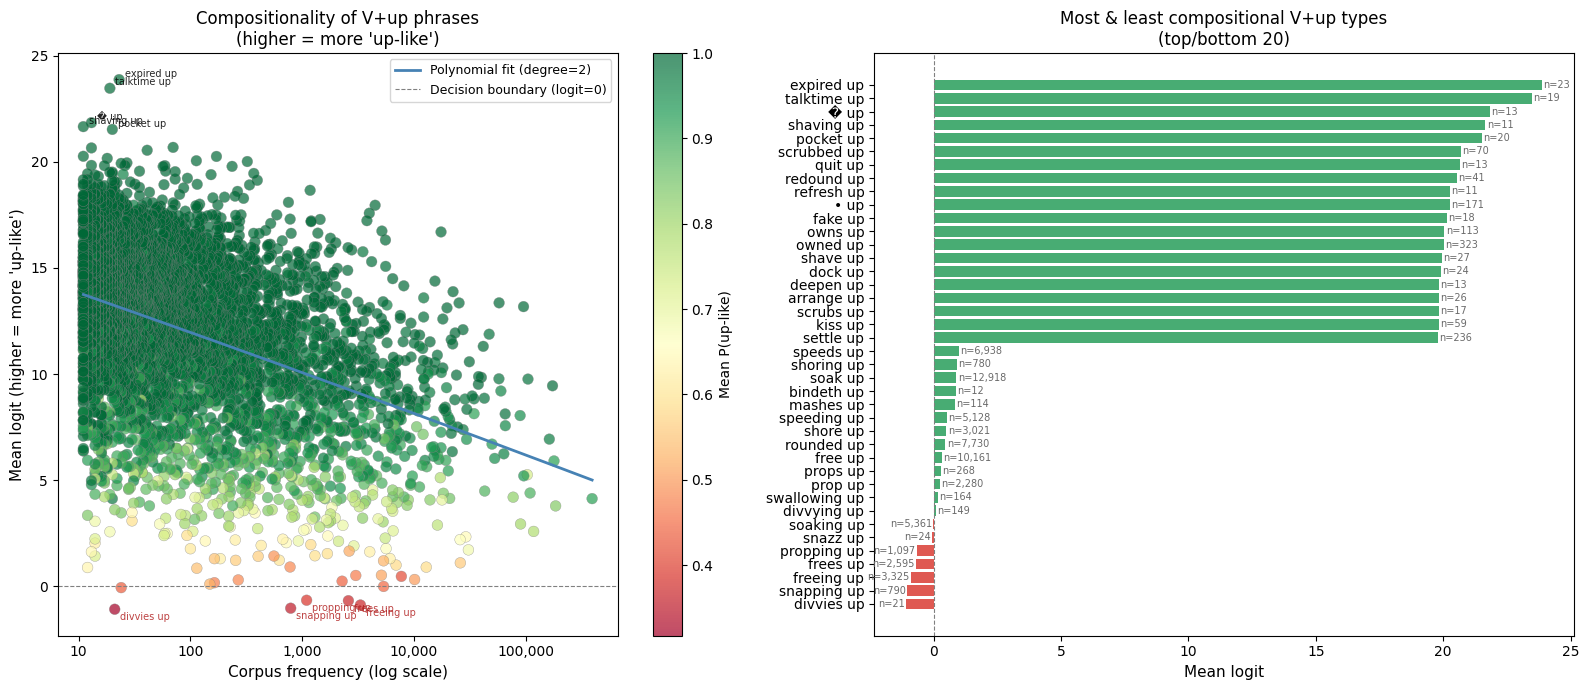

2026-02-26 05:17:02,884 Plot saved to vup_compositionality.png



Spearman correlation (log-frequency vs mean logit): -0.372
(negative = higher frequency → less compositional, as expected for lexicalized phrasal verbs)

Polynomial coefficients (degree=2): [-0.0160259  -1.81272862 15.65073122]


In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Aggregate to one row per verb_up type
summary_df = (
    results_df
    .groupby(["verb_up", "frequency"])
    .agg(
        mean_up_prob   = ("up_probability", "mean"),
        classifier_acc = ("classifier_pred", "mean"),
        mean_logit     = ("logit", "mean"),
        n_sentences    = ("classifier_pred", "count"),
    )
    .reset_index()
    .sort_values("frequency", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Plot 1: scatter with log-frequency x-axis and polynomial best-fit ---
ax = axes[0]

log_freq = np.log10(summary_df["frequency"])
logits   = summary_df["mean_logit"].values

sc = ax.scatter(
    log_freq,
    logits,
    c=summary_df["mean_up_prob"],
    cmap="RdYlGn",
    alpha=0.7,
    edgecolors="grey",
    linewidths=0.3,
    s=60,
)
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Mean P(up-like)", fontsize=10)

# Polynomial best-fit line (degree=2) in log-frequency space
poly_deg  = 2
coeffs    = np.polyfit(log_freq, logits, poly_deg)
x_smooth  = np.linspace(log_freq.min(), log_freq.max(), 300)
y_smooth  = np.polyval(coeffs, x_smooth)
ax.plot(x_smooth, y_smooth, color="steelblue", linewidth=2,
        label=f"Polynomial fit (degree={poly_deg})")

# Annotate extremes (still using log_freq for position)
for _, row in summary_df.nlargest(5, "mean_logit").iterrows():
    ax.annotate(row["verb_up"], (np.log10(row["frequency"]), row["mean_logit"]),
                fontsize=7, alpha=0.85,
                xytext=(4, 2), textcoords="offset points")
for _, row in summary_df.nsmallest(5, "mean_logit").iterrows():
    ax.annotate(row["verb_up"], (np.log10(row["frequency"]), row["mean_logit"]),
                fontsize=7, alpha=0.85, color="firebrick",
                xytext=(4, -8), textcoords="offset points")

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8, label="Decision boundary (logit=0)")

# Format x-axis ticks as original frequency values (10^x)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{int(10**x):,}")
)
ax.set_xlabel("Corpus frequency (log scale)", fontsize=11)
ax.set_ylabel("Mean logit (higher = more 'up-like')", fontsize=11)
ax.set_title("Compositionality of V+up phrases\n(higher = more 'up-like')", fontsize=12)
ax.legend(fontsize=9)

# --- Plot 2: top/bottom 20 types as horizontal bar chart ---
ax2 = axes[1]
n_show = 20
top    = summary_df.nlargest(n_show, "mean_logit")
bottom = summary_df.nsmallest(n_show, "mean_logit")
bar_df = pd.concat([top, bottom]).drop_duplicates("verb_up")
bar_df = bar_df.sort_values("mean_logit", ascending=True)

colors = ["#d73027" if l < 0 else "#1a9850" for l in bar_df["mean_logit"]]
bars   = ax2.barh(bar_df["verb_up"], bar_df["mean_logit"], color=colors, alpha=0.8)

for bar, (_, row) in zip(bars, bar_df.iterrows()):
    x_pos = bar.get_width() + 0.05 if bar.get_width() >= 0 else bar.get_width() - 0.05
    ha    = "left" if bar.get_width() >= 0 else "right"
    ax2.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f"n={row['frequency']:,}",
        va="center", ha=ha, fontsize=7, color="dimgray"
    )

ax2.axvline(0, color="grey", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Mean logit", fontsize=11)
ax2.set_title(f"Most & least compositional V+up types\n(top/bottom {n_show})", fontsize=12)

plt.tight_layout()
plt.savefig("vup_compositionality.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Plot saved to vup_compositionality.png")

# Spearman correlation
corr = summary_df["frequency"].apply(np.log10).corr(summary_df["mean_logit"], method="spearman")
print(f"\nSpearman correlation (log-frequency vs mean logit): {corr:.3f}")
print("(negative = higher frequency → less compositional, as expected for lexicalized phrasal verbs)")
print(f"\nPolynomial coefficients (degree={poly_deg}): {coeffs}")